# Predicting Aircraft Remaining Useful Life (RUL) (Solution)

In this laboratory, you will implement a full machine learning pipeline, from preprocessing to model evaluation. 

The dataset we use is a well-known one: the *Commercial Modular Aero-Propulsion System Simulation* or [CMAPSS](https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data). It contains comprehensive information on aircraft engine performance throughout their lifecycles. It is a widely used benchmark dataset of **synthetic** data in the field of predictive maintenance.

The idea is to use ML to predict the **Remaining Useful Life** (RUL) of aircraft components based on their historical performance data. Even if synthetic, the dataset may present real-world challenges (e.g., missing values, sensor noise, useless features). The data exploration part will be crucial to understand the dataset and extract the most relevant features.

Some explanations of the dataset is available at the link above.

## Goals
The goal of this lab is to guide students towards a higher level of autonomy when dealing with ML problems, particularly regression-based predictive maintenance problems.

This document provides just the skeleton of your program, reminding you of the main steps to be accomplished. Feel free to use any information available as well as code from old labs.

At the end of this lab, you will be able to:
- Develop a full Machine Learning pipeline starting from a skeleton.
- Train, tune, and properly evaluate different ML models (k-nn, decision tree, and random forest).

## Methodology

### Data Acquisition
Utilize the NASA C-MAPSS dataset, specifically subset **FD001**, which contains:
- **Train trajectories**: 100
- **Test trajectories**: 100
- **Operating Conditions**: ONE (Sea Level)
- **Fault Modes**: ONE (HPC Degradation)

### Feature Engineering
Extract relevant features from the raw data, such as sensor readings, operating conditions, and maintenance history.

### Model Selection and Training
Experiment with various regression and classification models, including but not limited to:
- k-Nearest Neighbors (k-NN)
- Decision Tree
- Random Forest
- [Optional] Naive Bayes
- [Optional] Support Vector Machine (SVM)
- [Optional] ...

### Model Evaluation
Assess the performance of each model using appropriate metrics, such as:
- **Mean Absolute Error (MAE)**
- **Root Mean Squared Error (RMSE)**
- **R-squared Score**

By the end of this lab, you should have a trained ML model capable of predicting aircraft engine RUL and be able to compare different approaches to determine the most effective predictive maintenance strategy.

---

## 1 Data exploration 

### 1.1 Load the data
NOTE: don't worry if you see a warning after running the cell below (something like "*TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html from .autonotebook import tqdm as notebook_tqdm*"). It's normal.

In [1]:
# Import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

plt.style.use('bmh') # Use bmh style for plots

The .txt files used for traing, validation and test come without headers. Here below we provide the headers for the columns. 

In [2]:
column_names = ['engine', 'time', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sm_{i}' for i in range(1, 22)]

The first five columns are:
1) Unit number (Engine number)
2) Time, in cycles
3) Operational setting 1
4) Operational setting 2
5) Operational setting 3

The operational settings (columns 3 to 5) are parameters that influence the engine's performance and operating conditions. While the dataset documentation does not specify the exact nature of these settings, they typically represent variables such as altitude, throttle resolver angle, and Mach number, which are known to substantially affect engine performance. These settings are included in the data to provide context for the sensor measurements and to facilitate the development of prognostic models.  As we do not know the exact nature of these settings, we will treat them as continuous variables and we will need to check their importance in the feature selection process.

The remaining columns are sensor measurements (therefore `sm`). Below, we provide a dictionary that maps the *sensor measurements* columns to their names that we got from the paper accompanying the dataset. If you are interested in the details of the sensors, you can check the paper (these data comes from Table 2). 

```python

In [3]:
# assign names to columns, save in dict_list 
Sensor_dictionary={}
dict_list=[ "(Fan inlet temperature) (◦R)", #°R stands for Rankine scale. In general, scientists favor the Kelvin scale over Rankine. But hey, americans ;-)
"(LPC outlet temperature) (◦R)",
"(HPC outlet temperature) (◦R)",
"(LPT outlet temperature) (◦R)",
"(Fan inlet Pressure) (psia)",              # PSIA - PSI Absolute - Absolute pressure is measured relative to a full vacuum
"(bypass-duct pressure) (psia)",
"(HPC outlet pressure) (psia)",
"(Physical fan speed) (rpm)",
"(Physical core speed) (rpm)",
"(Engine pressure ratio(P50/P2)",
"(HPC outlet Static pressure) (psia)",
"(Ratio of fuel flow to Ps30) (pps/psia)",
"(Corrected fan speed) (rpm)",
"(Corrected core speed) (rpm)",
"(Bypass Ratio) ",
"(Burner fuel-air ratio)",
"(Bleed Enthalpy)",
"(Required fan speed)",
"(Required fan conversion speed)",
"(High-pressure turbines Cool air flow)",
"(Low-pressure turbines Cool air flow)" ]

i=1
for x in dict_list :
    Sensor_dictionary[f'sm_{i}']=x
    i+=1
Sensor_dictionary

{'sm_1': '(Fan inlet temperature) (◦R)',
 'sm_2': '(LPC outlet temperature) (◦R)',
 'sm_3': '(HPC outlet temperature) (◦R)',
 'sm_4': '(LPT outlet temperature) (◦R)',
 'sm_5': '(Fan inlet Pressure) (psia)',
 'sm_6': '(bypass-duct pressure) (psia)',
 'sm_7': '(HPC outlet pressure) (psia)',
 'sm_8': '(Physical fan speed) (rpm)',
 'sm_9': '(Physical core speed) (rpm)',
 'sm_10': '(Engine pressure ratio(P50/P2)',
 'sm_11': '(HPC outlet Static pressure) (psia)',
 'sm_12': '(Ratio of fuel flow to Ps30) (pps/psia)',
 'sm_13': '(Corrected fan speed) (rpm)',
 'sm_14': '(Corrected core speed) (rpm)',
 'sm_15': '(Bypass Ratio) ',
 'sm_16': '(Burner fuel-air ratio)',
 'sm_17': '(Bleed Enthalpy)',
 'sm_18': '(Required fan speed)',
 'sm_19': '(Required fan conversion speed)',
 'sm_20': '(High-pressure turbines Cool air flow)',
 'sm_21': '(Low-pressure turbines Cool air flow)'}

In [4]:
# We configure the dataset to be downloaded in the .data folder.
os.environ['KAGGLEHUB_CACHE'] = './data/'

In [5]:
# (if not already in the data folder) we download the data from kaggle website
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

Give a look at the dataset in the `path` directory. The dataset is composed of multiple .txt files. You can use the `read_csv` function from the `pandas` library to load the data.

Some points to note:
- Data is separated by a single space, and the columns do not have headers. 
- Files have three prefixes: `train_`, `test_`, and `RUL_`.
    - The `RUL_` files contain the Remaining Useful Life values for the test trajectories. In other words, this is the ground truth for the test set, the value we want to predict.
    - The `train_` and `test_` files contain the sensor readings and operational settings for the engines. They do not have labels (a.k.a, target values or `y`). We will need to compute them.
- We will start our analyis using the `_FD001.txt` files. Later, we can extend our analysis to the other datasets, perhaps checking whether a model trained on one dataset can be used to predict the RUL of another dataset.

NOTE: you will get a warning message when you run the code below, but you can ignore it.

(*something like: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False [...]*)

In [6]:
# Load the data into pandas dataframes

# os independent path building
data_train_path = os.path.join(path, "CMaps", "train_FD001.txt") # only training data, no label (RUL)
data_test_path = os.path.join(path, "CMaps", "test_FD001.txt") # only test data, no label (RUL)
y_test_path = os.path.join(path, "CMaps", "RUL_FD001.txt") # only RUL (label) for the test set

# load training data
train_df = pd.read_csv(data_train_path, sep=' ', header=None, names=column_names , index_col=False)

# load test data
test_data_df = pd.read_csv(data_test_path, sep=' ', header=None, names=column_names, index_col=False)
test_y_df = pd.read_csv(y_test_path , header=None , names=['RUL'])

C:\Users\ingno\AppData\Local\Temp\ipykernel_37112\1897567655.py:9: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  train_df = pd.read_csv(data_train_path, sep=' ', header=None, names=column_names , index_col=False)
C:\Users\ingno\AppData\Local\Temp\ipykernel_37112\1897567655.py:12: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  test_data_df = pd.read_csv(data_test_path, sep=' ', header=None, names=column_names, index_col=False)


In [7]:
# we check the shape of the test data
print(test_data_df.shape)
print(test_y_df.shape)


(13096, 26)
(100, 1)


In [8]:
# We need to associate the y values to the test data.
# We will make prediction only for the last cycle of each engine, so we need to find the last cycle of each engine.
# Then we will associate the RUL value (test_y_df) to the last cycle of each engine.

# get the last cycle of each engine
last_cycle = test_data_df.groupby('engine').time.idxmax()

# associate the RUL value to the last cycle of each engine
test_data_df = test_data_df.loc[last_cycle]

# we check the shape of the test data
print(test_data_df.shape)
print(test_y_df.shape)


(100, 26)
(100, 1)


### 1.2 Explore the data

#### 1.2.1 Explore the training set

In [9]:
# Display the first 10 rows of the training set
train_df.head(10)

,engine,time,op_setting_1,op_setting_2,op_setting_3,sm_1,sm_2,sm_3,sm_4,sm_5,...,sm_12,sm_13,sm_14,sm_15,sm_16,sm_17,sm_18,sm_19,sm_20,sm_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


In [10]:
# Display the shape of the training set
train_df.shape

(20631, 26)

In [11]:
# Display the information of the training set (e.g., datatype, number of non-null values, etc.)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   engine        20631 non-null  int64  
 1   time          20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sm_1          20631 non-null  float64
 6   sm_2          20631 non-null  float64
 7   sm_3          20631 non-null  float64
 8   sm_4          20631 non-null  float64
 9   sm_5          20631 non-null  float64
 10  sm_6          20631 non-null  float64
 11  sm_7          20631 non-null  float64
 12  sm_8          20631 non-null  float64
 13  sm_9          20631 non-null  float64
 14  sm_10         20631 non-null  float64
 15  sm_11         20631 non-null  float64
 16  sm_12         20631 non-null  float64
 17  sm_13         20631 non-null  float64
 18  sm_14         20631 non-nu

In [12]:
# Display the statistics of the training set
train_df.describe()

,engine,time,op_setting_1,op_setting_2,op_setting_3,sm_1,sm_2,sm_3,sm_4,sm_5,...,sm_12,sm_13,sm_14,sm_15,sm_16,sm_17,sm_18,sm_19,sm_20,sm_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [13]:
# Check the number of unique values in each column of the training set
train_df.nunique()

engine           100
time             362
op_setting_1     158
op_setting_2      13
op_setting_3       1
sm_1               1
sm_2             310
sm_3            3012
sm_4            4051
sm_5               1
sm_6               2
sm_7             513
sm_8              53
sm_9            6403
sm_10              1
sm_11            159
sm_12            427
sm_13             56
sm_14           6078
sm_15           1918
sm_16              1
sm_17             13
sm_18              1
sm_19              1
sm_20            120
sm_21           4745
dtype: int64

**Question/Hint:**
- Some features have **one** unique value. What does that means in your opinion? We like them or not? Why?

**Answer**:
<details>
<summary><i>Click to reveal/hide the answer</i></summary>

- Features with only one unique value are constant features. They do not provide any information to the model and can be removed. In fact, they can even harm the model's performance. Therefore, we should (and we will) remove them from the dataset.

</details>

In [14]:
# We check if there are any missing values in the training set
train_df.isnull().any()


engine          False
time            False
op_setting_1    False
op_setting_2    False
op_setting_3    False
sm_1            False
sm_2            False
sm_3            False
sm_4            False
sm_5            False
sm_6            False
sm_7            False
sm_8            False
sm_9            False
sm_10           False
sm_11           False
sm_12           False
sm_13           False
sm_14           False
sm_15           False
sm_16           False
sm_17           False
sm_18           False
sm_19           False
sm_20           False
sm_21           False
dtype: bool

#### 1.2.2 Label the data

As we mentioned above, the training set does not have a column for the Remaining Useful Life (RUL). This is because the RUL is a calculated value based on the number of cycles before the engine fails. The RUL is not given directly in the dataset, but it can be calculated using the following formula:

$$RUL = TTF - Cycles$$

Where:
- $RUL$ is the Remaining Useful Life
- $TTF$ is the Total Time to Failure (the number of cycles the engine runs before failure)
- $Cycles$ is the number of cycles the engine has already run


In [15]:
# Backup the training set
# We are going to modify the training set. A good idea is to work on a copy of it. So, if we mess up, (and we probably will) we can always go back to the original data.

tr_df = train_df.copy() # tr_df is the copy of the training set

In [16]:
# We define the function to calculate the Remaining Useful Life (RUL) of the engines
def calculate_rul(df):
    # We get the maximum cycle of each engine
    max_cycle = df.groupby('engine')['time'].transform("max")
    # We calculate the RUL
    df['RUL'] = max_cycle - df['time']
    return df

calculate_rul(tr_df)

,engine,time,op_setting_1,op_setting_2,op_setting_3,sm_1,sm_2,sm_3,sm_4,sm_5,...,sm_13,sm_14,sm_15,sm_16,sm_17,sm_18,sm_19,sm_20,sm_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


Suggestion: the function above added a column to the dataframe. Give it a look and check if the values are what you expected.

In [17]:
# max, or failure time for each engine, or max time cycle, that engine has worked.
failure_time = tr_df.groupby('engine')['RUL'].max()

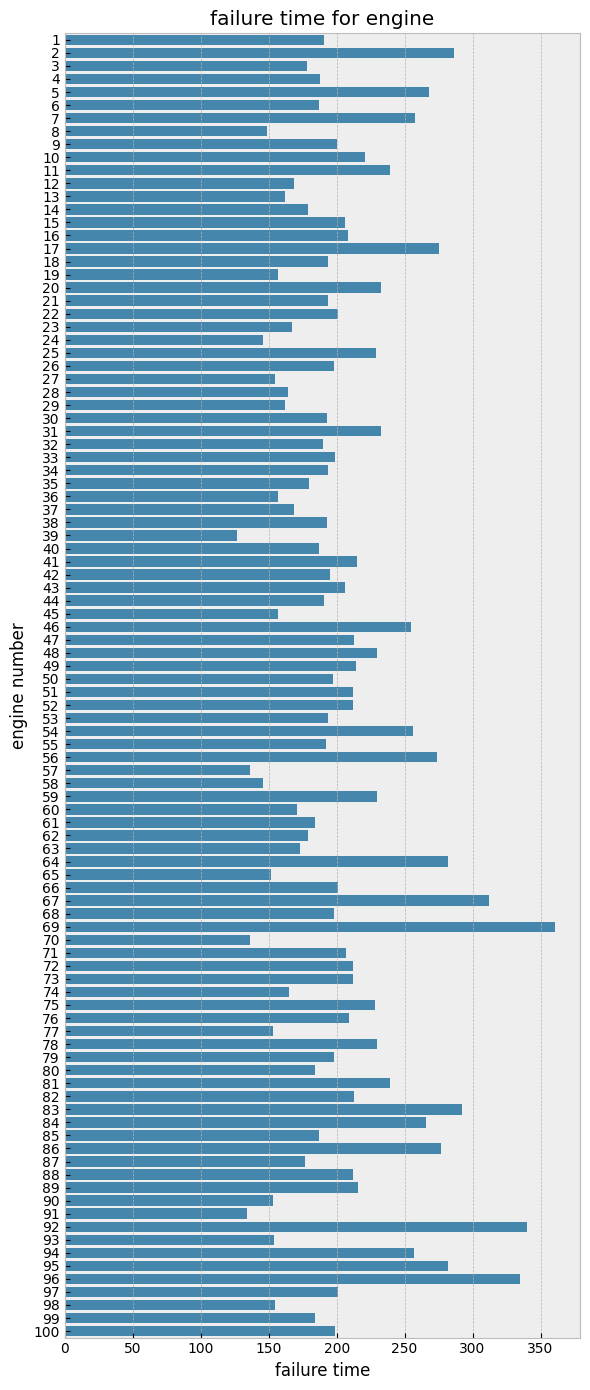

In [18]:
# plot the failure time for each engine
plt.figure(figsize = (6,14))
sns.barplot(y = failure_time.index, x = failure_time.values , orient='h')
plt.title('failure time for engine')
plt.xlabel('failure time')
plt.ylabel('engine number')
plt.tight_layout()
plt.show()

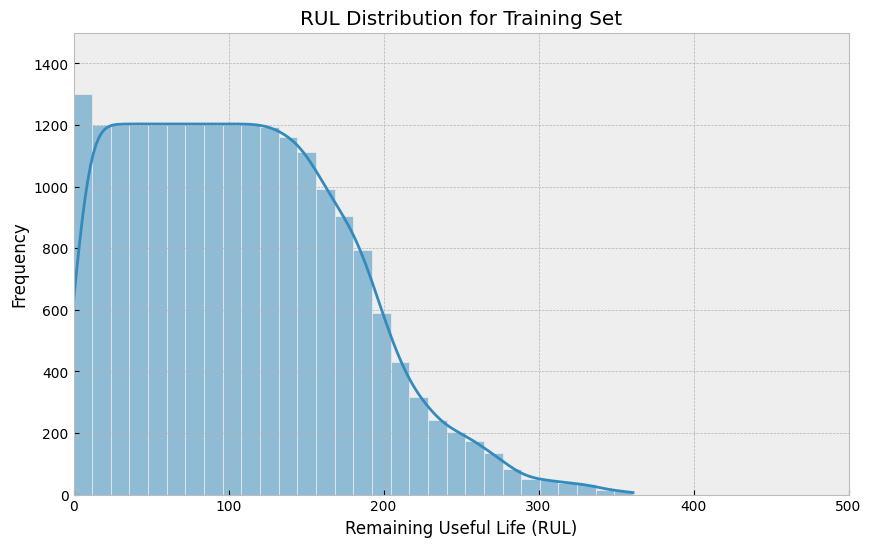

In [19]:
# We plot the RUL distribution for the training set
plt.figure(figsize=(10, 6))
sns.histplot(tr_df['RUL'], bins=30, kde=True)
plt.title('RUL Distribution for Training Set')
plt.xlabel('Remaining Useful Life (RUL)')
plt.ylabel('Frequency')
plt.xlim(0, 500)
plt.ylim(0, 1500)
plt.show()


**Question**:
- Is the training set balanced or unbalanced? Why?

**Answer**:
<details>
<summary><i>Click to reveal/hide the answer</i></summary>
Most of the time, the analysis balanced/unbalanced is reserved for classification problems. Most of the existing methods for dealing with imbalanced data are only for classification problems, as well. However, we can observe that the dataset is "unbalanced" because the RUL values are not uniformly distributed (only a few engines have a high RUL). This can lead to a model that is biased towards predicting low RUL values. For further information you may want to check this <a href="https://towardsdatascience.com/strategies-and-tactics-for-regression-on-imbalanced-data-61eeb0921fca/">article</a>.

#### 1.2.3 Correlation analysis
To complete our data exploration, we will analyze the correlation between features and between the features and the target variable. This will help us understand which features are most relevant for predicting the RUL.

In [20]:
# Print a correlation matrix
df_corr = tr_df.corr()
mask = np.tril(np.ones(df_corr.shape),k = -1).astype(bool)
df_corr = df_corr.where(mask)
df_corr

,engine,time,op_setting_1,op_setting_2,op_setting_3,sm_1,sm_2,sm_3,sm_4,sm_5,...,sm_13,sm_14,sm_15,sm_16,sm_17,sm_18,sm_19,sm_20,sm_21,RUL
engine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,0.078753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
op_setting_1,-0.017895,-0.004527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
op_setting_2,-0.006197,0.016132,0.011660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
op_setting_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sm_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sm_2,0.014133,0.549898,0.009030,0.007266,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sm_3,0.012621,0.543947,-0.005651,0.009068,NaN,NaN,0.602610,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sm_4,0.026116,0.624577,0.009544,0.014673,NaN,NaN,0.714949,0.678413,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sm_5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: title={'center': 'correlation'}>

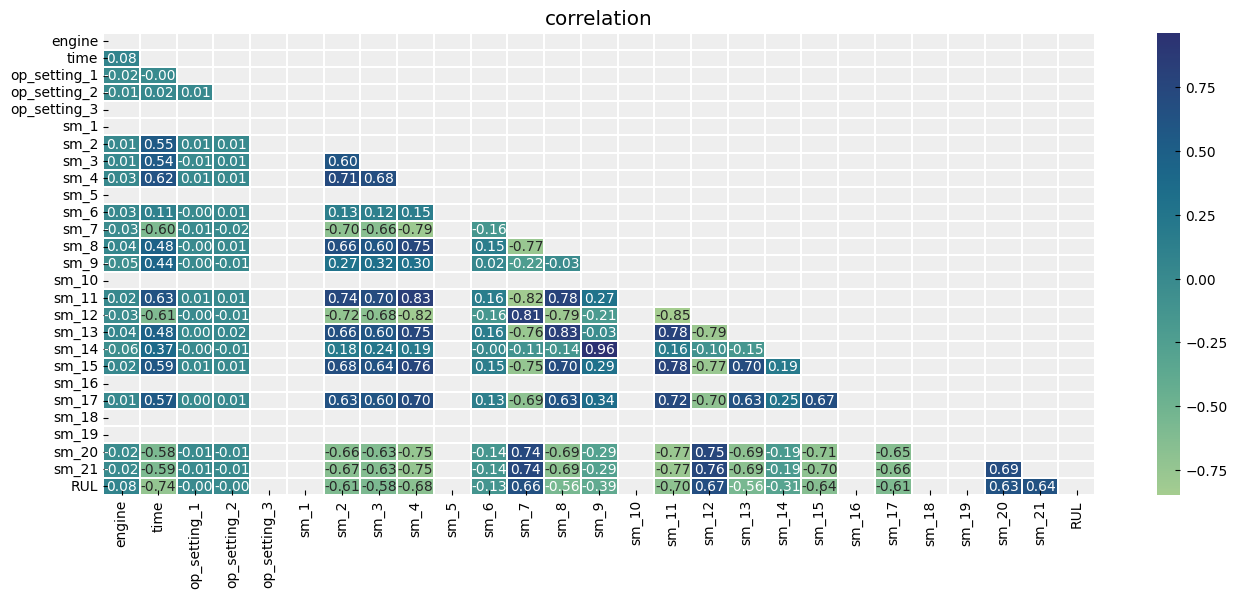

In [21]:
# Plot the correlation matrix
plt.figure(figsize = (16,6))
plt.grid() , plt.title('correlation')
sns.heatmap(df_corr , annot=True , fmt = '0.2f' , cmap='crest' , linewidths=0.01)

<Axes: >

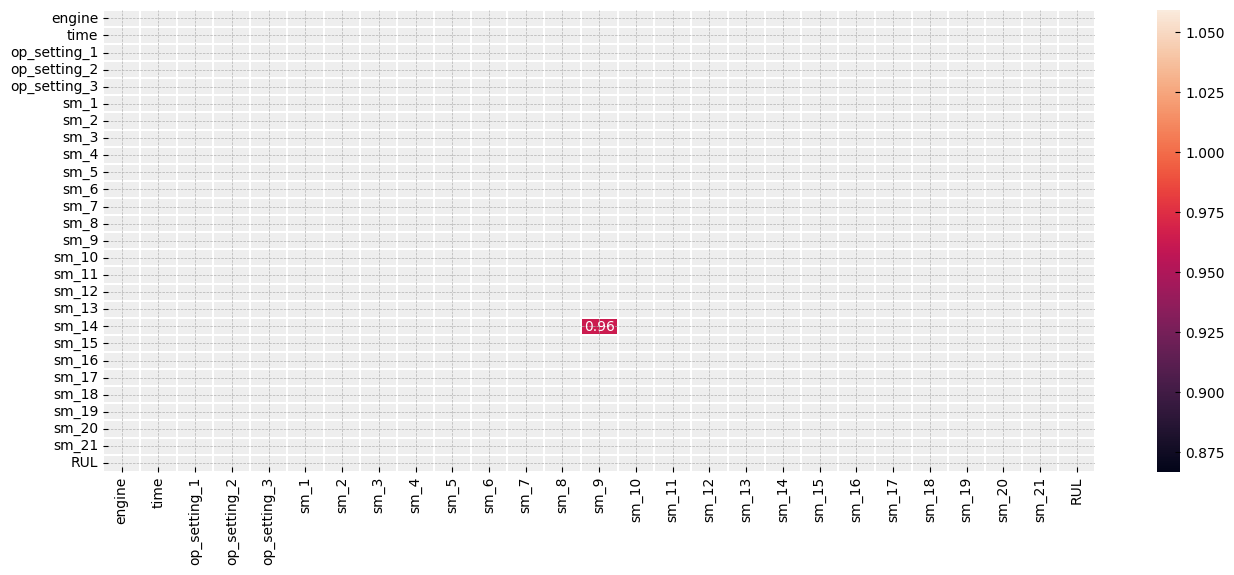

In [22]:
# visualization high correlated features 
plt.figure(figsize = (16,6))
mask = df_corr.where( abs(df_corr) > 0.95 ).isna()
sns.heatmap(df_corr , annot=True , fmt = '0.2f' , linewidths=0.1 , mask = mask )

**Questions**:
- Why is it important to know the type (numerical vs. categorical) of a feature?
- Why is it important to count the number of unique values in a feature?
- Why is it important to understand correlations? Is it good to have features highly correlated with each other? Is it good to have features highly correlated with the target? 
- Is our dataset unbalanced? Why is it important to know that? List possible solutions for dealing with an unbalanced dataset.
- Are there missing values in our dataset?
- Is this a regression or classification problem? Why?


**Answers**:
- It is important to know the type of a feature because it determines the type of analysis we can perform on it. For example, we can perform mathematical operations on numerical features, but not on categorical features. We can rescale numerical features, but not categorical features. Also, some models can only handle numerical features (we need to encode categorical features). Also imputation strategies are different for numerical and categorical features.
- It is important to count the number of unique values in a feature because it helps us understand the nature of the feature. If a feature has only one unique value, it does not provide any information to the model and can be dropped.
- It is important to understand correlations because it helps us understand the relationships between features and between features and the target. Highly correlated features can introduce [multicollinearity](https://en.wikipedia.org/wiki/Multicollinearity), which can affect the model's performance. Highly correlated features with the target can be good predictors.
- Our dataset cannot be unbalanced because it is a regression problem. Unbalanced datasets are a problem for classification problems because the model can be biased towards the majority class. Possible solutions for dealing with an unbalanced dataset include: undersampling, oversampling, and using algorithms that handle unbalanced datasets (e.g., SMOTE).
- There are no missing values in our dataset. It is a simulated dataset, so it is complete.
- As mentioned above, this is a regression problem because the target variable is continuous (RUL).

## 2 Preprocessing the data

### 2.1 Drop useless columns

We should consider dropping columns that do not provide useful information for predicting the RUL:
- Columns with only one unique value
- Columns with very high correlation (>|0.95|) with other columns. We can just keep one of them.
- Columns with very low correlation with the target variable (<|0.1|)
- Other columns that do not provide useful information for predicting the RUL

NOTE: we will need to drop the same columns from the test set as well. We will do that in Section 5.

In [23]:
# We drop the useless columns, if any
# We drop columns that have only one unique value
col_to_drop_unique_value = ['op_setting_3', 'sm_1', 'sm_5','sm_10','sm_16','sm_18', 'sm_19']
col_to_drop_multicollinearity = ['sm_14']
col_to_dop_low_correlation_with_target = ['engine', 'op_setting_1', 'op_setting_2']
time = ['time']

# we put put all columns to drop in one list
col_to_drop = col_to_drop_unique_value + col_to_drop_multicollinearity + col_to_dop_low_correlation_with_target #+ time

# drop the columns
tr_df.drop(columns=col_to_drop, inplace=True)

**Question/Hint**:
- Should we drop the `time` column? Why?

**Answer**:
<details>
<summary><i>Click to reveal/hide the answer</i></summary>

The answer is **not** straightforward. The `time` column can be useful for predicting the RUL because the RUL is calculated based on the number of cycles before the engine fails. Of course, knowing that an engine has many cycles on his past is a good indicator of its remaining lifespan. However, the time column is also linearly correlated with the RUL, so it can introduce target leakage (i.e., the model can "cheat", learning the target from the features). In this case, we should drop the time column. The solution? Test with and without the time column and check the model's performance on a test set. If the model performs better without the time column, we should drop it.

</details>

### 2.2 Split the data into training and test set

In [24]:
# Already done

### 2.3 Imputation - fill missing values (if any)

In [25]:
# No missing values in the training set

### 2.4 Separate the features X, from the label y

In [26]:
# We separate the features and the target
X_train = tr_df.drop(columns=['RUL'])
y_train = tr_df['RUL']

### 2.5 Feature scaling
NOTE: Decision trees and random forests do not require feature scaling. However, k-NN does. Therefore, we will scale the features for all models.

In [ ]:
# We rescale the features We use scikit-learn's scalers. Consider using the MinMaxScaler, the StandardScaler, or the RobustScaler.
# We use the RobustScaler because it is robust to outliers.
# Note: all features are numerical, so we do not need to separate the numerical features from the categorical features.
from sklearn.preprocessing import RobustScaler, StandardScaler

# We get the columns of the features (it will be useful to keep the data in a pandas dataframes)
columns = X_train.columns

scaler = RobustScaler()
X_train[columns] = scaler.fit_transform(X_train[columns])


In [28]:
X_train.head()

,time,sm_2,sm_3,sm_4,sm_6,sm_7,sm_8,sm_9,sm_11,sm_12,sm_13,sm_15,sm_17,sm_20,sm_21
0,-1.565170,-1.721725,-0.134255,-0.925936,0.141683,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.603816,-0.781710,1.348493,1.194427
1,-1.550652,-1.061780,0.211528,-0.643726,0.141683,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.275852,-0.781710,1.016528,1.236922
2,-1.536134,-0.661813,-0.413166,-0.525953,0.141683,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.649144,-2.073094,0.739891,0.503423
3,-1.521616,-0.661813,-1.261314,-0.784831,0.141683,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-1.971665,-0.781710,0.352598,0.777792
4,-1.507098,-0.621816,-1.251528,-0.301518,0.141683,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.339845,-0.136018,0.463253,1.059552


### 2.6 Encode the categorical features

In [29]:
# We encode categorical features, if any
# There are no categorical features in the training set

### 2.7 Encode the Labels

In [30]:
# Encode the labels (label encoder)
# we do not need to do this, as this is a regression problem

**Questions**:
- In this case, do we need to split the data into training and test sets? Why?
- Do we need to scale the features? Why?
- Do we need to encode the categorical features? Why?
- When do we need to encode the labels? Can you provide an example of a model that requires encoded labels?

All these "why" questions are very important to understand the reasons behind each step in the preprocessing phase. This understanding will help you to know when to apply each step in future projects.

**Answers**:
- In this case, we do not need to split the data into training and test sets because the dataset is already split into training and test sets. We will use the training set to train the model and the test set to evaluate the model.
- We need to scale the features because some machine learning algorithms are sensitive to the scale of the input features. For example, k-NN, SVM and Neural Network are sensitive to the scale of the input features. Scaling the features ensures that all features contribute equally to the model. Sometimes, scaling the features can also improve the convergence of the optimization algorithm.
- We do not have categorical features in this dataset. If we had categorical features, we would need to encode them because machine learning algorithms require numerical input. We can use one-hot encoding or label encoding to encode categorical features.
- We do not need to encode the labels because the target variable is continuous (RUL). If the target variable was categorical, we would need to encode the labels. For exemple, if we were predicting the Remaining Useful Life in classes (e.g., low, medium, high), we would need to encode the labels, e.g., low=0, medium=1, high=2 or using one-hot encoding.


## 3 Model Selection and Training

Now it's time to train and evaluate some models!

The code below is structured to allow easy experimentation with different models and comparison of their performance.

We will leverage [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html) to optimize the hyperparameters of the models. GridSearchCV systematically tests various combinations of hyperparameters and uses cross-validation to assess the performance of each combination, ensuring a robust selection of the best configuration.

*NOTE: To perform the grid search and print the results, we will use the functions defined above.*

In [31]:
# Import libraries (we will use GridSearchCV to find the best hyperparameters for each model)
from sklearn.model_selection import GridSearchCV

In [32]:
# Define a function to find the best hyperparameters for a model
# Remember, the scoring depends on the model (e.g., for regression, we use 'r2' or 'neg_mean_squared_error'; for classification, we may use 'accuracy' or 'f1', etc.)

# Return the model with the best hyperparameters for the selected scoring (the scoring defined here will be used to optimize the hyperparameters)
def find_best_hyperparameters(regressor, param_grid, X_train, y_train, scoring = 'r2'):
    # create the grid search object
    grid_search = GridSearchCV(regressor, param_grid, cv=5, scoring=scoring, return_train_score=True, n_jobs=-1, verbose=2) # use all the cores of the CPU
    # find the best hyperparameters
    grid_search.fit(X_train, y_train)
    # print the best hyperparameters
    print("Best hyperparameters: {}".format(grid_search.best_params_))
    # print the best score
    print("Best score (r2): {:.2f}".format(grid_search.best_score_))
    # return the model with the best hyperparameters
    return grid_search.best_estimator_

In [33]:
# train and evaluate the model with the best hyperparameters using cross-validation

from sklearn.model_selection import cross_validate
def print_cross_validation_results(regressor, X_train, y_train):
    # cross validate the model
    scoring = ['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error']
    cv_results = cross_validate(regressor, X_train, y_train, cv=5, scoring = scoring, n_jobs=-1, return_train_score=True)
    # Print the results
    print("Train R^2: {:.2f}".format(cv_results['train_r2'].mean()))
    print("Validation R^2: {:.2f}".format(cv_results['test_r2'].mean()))
    print("Train MAE: {:.2f}".format(-cv_results['train_neg_mean_absolute_error'].mean()))
    print("Validation MAE: {:.2f}".format(-cv_results['test_neg_mean_absolute_error'].mean()))
    print("Train RMSE: {:.2f}".format(-cv_results['train_neg_root_mean_squared_error'].mean()))
    print("Validation RMSE: {:.2f}".format(-cv_results['test_neg_root_mean_squared_error'].mean()))

*NOTE: For ALL models below, we will use these two functions to perform the grid search and print the results.*

### 3.1 Train a k-Nearest Neighbors (k-NN) model
(Feel free to use SVM instead of k-NN if you want to)

In [34]:
# Import the k-nn classifier
from sklearn.neighbors import KNeighborsRegressor

# Define the parameter grid to explore
param_grid = {'n_neighbors': [1, 10, 20]}

# Create the regressor
knn_reg = KNeighborsRegressor()

# Find the best hyperparameters
knn_reg = find_best_hyperparameters(knn_reg, param_grid, X_train, y_train)

# Print the cross validation results
print_cross_validation_results(knn_reg, X_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best hyperparameters: {'n_neighbors': 20}
Best score (r2): 0.68
Train R^2: 0.74
Validation R^2: 0.68
Train MAE: 24.87
Validation MAE: 27.87
Train RMSE: 35.24
Validation RMSE: 38.57


### 3.2 Train a Decision Tree model

In [35]:
# Import the decision tree classifier
from sklearn.tree import DecisionTreeRegressor

# Define the parameter grid to explore
param_grid = {'max_depth': [None, 1, 3], 'min_samples_split': [2, 4, 10], 'min_samples_leaf': [1, 2, 5]}

# Create the regressor
dt_reg = DecisionTreeRegressor()

# Find the best hyperparameters
dt_reg = find_best_hyperparameters(dt_reg, param_grid, X_train, y_train)

# Print the cross validation results
print_cross_validation_results(dt_reg, X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best hyperparameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score (r2): 0.64
Train R^2: 0.67
Validation R^2: 0.64
Train MAE: 29.42
Validation MAE: 30.68
Train RMSE: 39.83
Validation RMSE: 40.60


**Questions**:
Describe the meaning of the hyperparameters:
- `max_depth`. What's the meaning of this hyperparameter? What happens if we set it to `None`?
- `min_samples_split`
- `min_samples_split`

**Answers**:
- `max_depth`: The maximum depth of the tree. If None, then nodes are expanded until all leaves are *pure* or until all leaves contain less than `min_samples_split` samples.
- `min_samples_split`: The minimum number of samples required to split an internal node. The default value is 2.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node. The default value is 1.

### 3.3 Train a Random Forest model

In [36]:
# Import the random forest classifier
from sklearn.ensemble import RandomForestRegressor

# Define the parameter grid to explore
param_grid = {'n_estimators': [10, 100], 'max_depth': [None, 1, 3], 'min_samples_split': [2, 4], 'min_samples_leaf': [1]}

# Create the regressor
rf_reg = RandomForestRegressor()

# Find the best hyperparameters
rf_reg = find_best_hyperparameters(rf_reg, param_grid, X_train, y_train)

# Print the cross validation results
print_cross_validation_results(rf_reg, X_train, y_train)

# Rank and print the feature importances with its corresponding feature name
feature_importances = rf_reg.feature_importances_
feature_names = X_train.columns
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
print(feature_importances)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best score (r2): 0.69
Train R^2: 0.96
Validation R^2: 0.69
Train MAE: 9.39
Validation MAE: 27.20
Train RMSE: 13.52
Validation RMSE: 37.77
   feature  importance
0     time    0.547089
8    sm_11    0.151394
7     sm_9    0.051558
3     sm_4    0.034671
9    sm_12    0.033213
11   sm_15    0.026811
5     sm_7    0.026707
14   sm_21    0.024780
2     sm_3    0.022721
1     sm_2    0.022116
13   sm_20    0.018045
6     sm_8    0.016475
10   sm_13    0.016036
12   sm_17    0.007587
4     sm_6    0.000796


**Questions**:
- Describe the meaning of the hyperparameters `n_estimators`. What are the possible values for this hyperparameter? An high value of `n_estimators` is always better?

**Answers**:
- `n_estimators`: The number of trees in the forest. The possible values for this hyperparameter are positive integers. A high value of `n_estimators` is not always better because it can increase the training time and the risk of overfitting.

### 3.4 learning_curve

Plotting a learning curve could help to see if the models are overfitting and/or if getting more data may help.

[learning_curve] Training set sizes: [ 1650  3300  4951  6601  8252  9902 11552 13203 14853 16504]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 out of  50 | elapsed:    2.8s remaining:    5.6s
[Parallel(n_jobs=-1)]: Done  34 out of  50 | elapsed:    6.7s remaining:    3.1s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   11.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 out of  50 | elapsed:    0.1s remaining:    0.3s


[learning_curve] Training set sizes: [ 1650  3300  4951  6601  8252  9902 11552 13203 14853 16504]


[Parallel(n_jobs=-1)]: Done  34 out of  50 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.


[learning_curve] Training set sizes: [ 1650  3300  4951  6601  8252  9902 11552 13203 14853 16504]


[Parallel(n_jobs=-1)]: Done  17 out of  50 | elapsed:   15.9s remaining:   30.9s
[Parallel(n_jobs=-1)]: Done  34 out of  50 | elapsed:   28.1s remaining:   13.2s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   44.6s finished


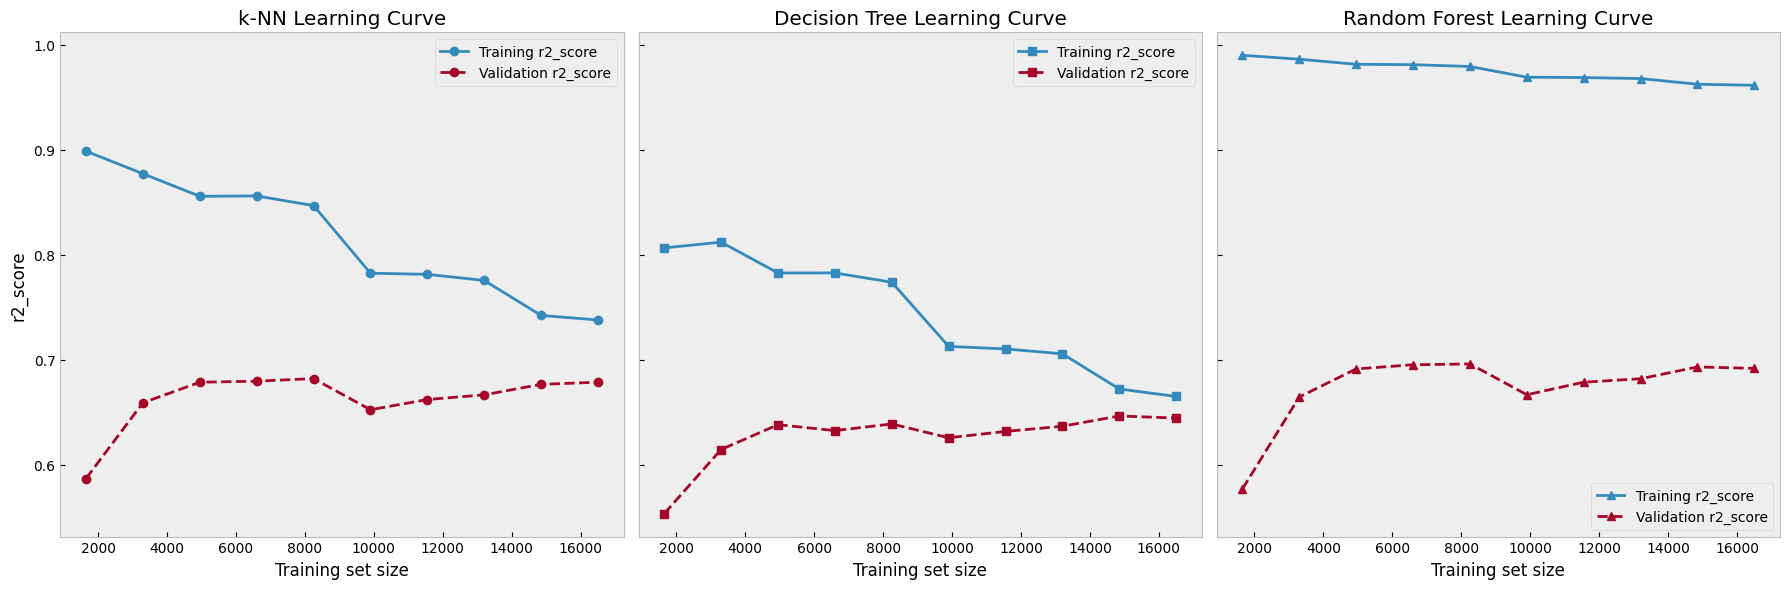

In [37]:
# Plot the learning curves for k-NN, Decision Tree, and Random Forest in separate subplots
# Keep the same y-axis for all the subplots to better compare the models
# Use the r2 score as the scoring metric. The higher the r2 score, the better the model.
from sklearn.model_selection import learning_curve

scorer = 'r2'

# We use R^2 as the scoring metric. The higher the R^2, the better the model.
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# k-NN learning curve
train_sizes, train_scores, validation_scores = learning_curve(knn_reg, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, n_jobs=-1, verbose=3, scoring=scorer)
train_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
axes[0].plot(train_sizes, train_scores_mean, label='Training r2_score', linestyle='-', marker='o')
axes[0].plot(train_sizes, validation_scores_mean, label='Validation r2_score', linestyle='--', marker='o')
axes[0].set_title('k-NN Learning Curve')
axes[0].set_xlabel('Training set size')
axes[0].set_ylabel('r2_score')
axes[0].legend()
axes[0].grid()

# Decision Tree learning curve
train_sizes, train_scores, validation_scores = learning_curve(dt_reg, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, n_jobs=-1, verbose=3, scoring=scorer)
train_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
axes[1].plot(train_sizes, train_scores_mean, label='Training r2_score', linestyle='-', marker='s')
axes[1].plot(train_sizes, validation_scores_mean, label='Validation r2_score', linestyle='--', marker='s')
axes[1].set_title('Decision Tree Learning Curve')
axes[1].set_xlabel('Training set size')
axes[1].legend()
axes[1].grid()

# Random Forest learning curve
train_sizes, train_scores, validation_scores = learning_curve(rf_reg, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, n_jobs=-1, verbose=3, scoring=scorer)
train_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
axes[2].plot(train_sizes, train_scores_mean, label='Training r2_score', linestyle='-', marker='^')
axes[2].plot(train_sizes, validation_scores_mean, label='Validation r2_score', linestyle='--', marker='^')
axes[2].set_title('Random Forest Learning Curve')
axes[2].set_xlabel('Training set size')
axes[2].legend()
axes[2].grid()

# Adjust layout
plt.tight_layout()
plt.show()

[learning_curve] Training set sizes: [ 1650  3300  4951  6601  8252  9902 11552 13203 14853 16504]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 out of  50 | elapsed:    3.4s remaining:    6.7s
[Parallel(n_jobs=-1)]: Done  34 out of  50 | elapsed:    7.0s remaining:    3.3s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   11.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.


[learning_curve] Training set sizes: [ 1650  3300  4951  6601  8252  9902 11552 13203 14853 16504]


[Parallel(n_jobs=-1)]: Done  17 out of  50 | elapsed:    0.1s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  34 out of  50 | elapsed:    0.3s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.


[learning_curve] Training set sizes: [ 1650  3300  4951  6601  8252  9902 11552 13203 14853 16504]


[Parallel(n_jobs=-1)]: Done  17 out of  50 | elapsed:   17.1s remaining:   33.4s
[Parallel(n_jobs=-1)]: Done  34 out of  50 | elapsed:   29.1s remaining:   13.7s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   45.3s finished


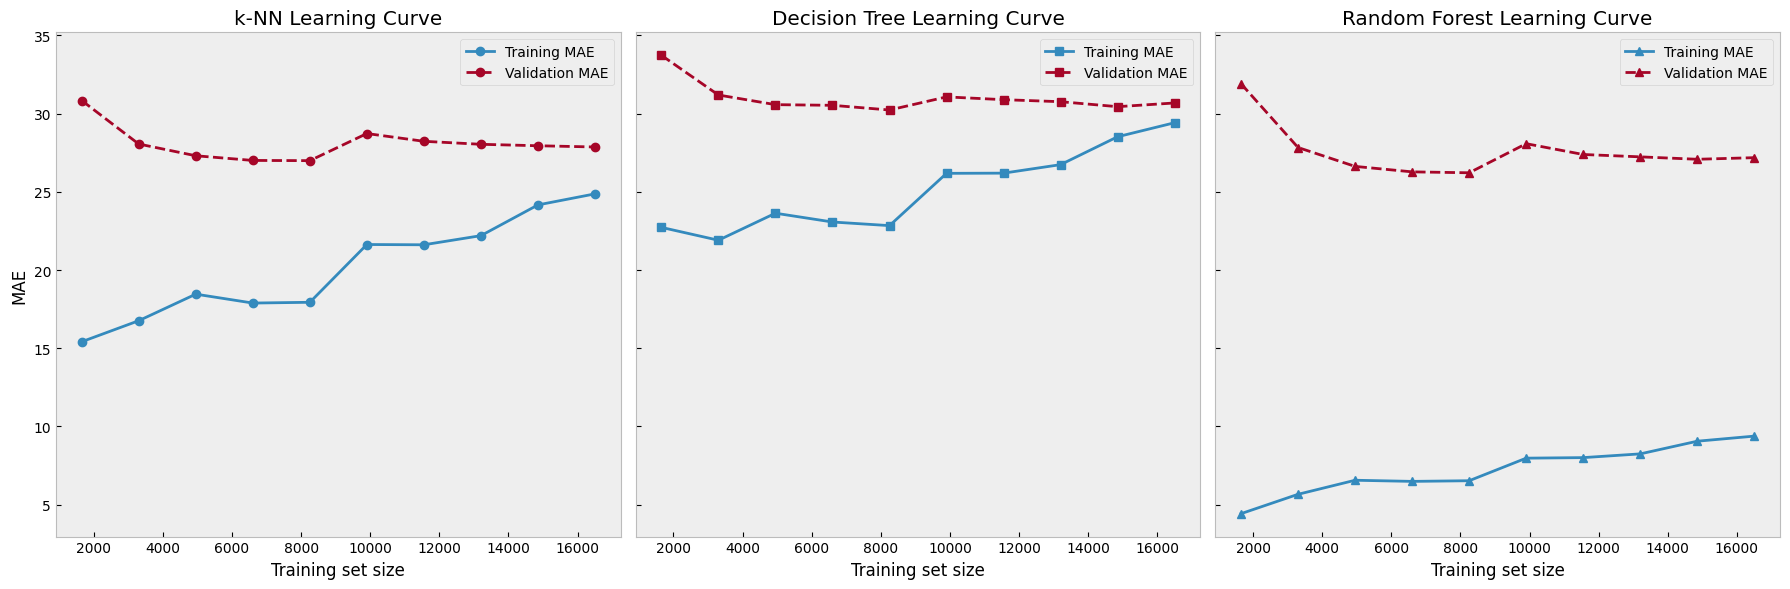

In [38]:
# We do the same with MAE. The lower the MAE, the better the model.
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

scorer = 'neg_mean_absolute_error'

# k-NN learning curve
train_sizes, train_scores, validation_scores = learning_curve(knn_reg, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, n_jobs=-1, verbose=3, scoring=scorer)
train_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
axes[0].plot(train_sizes, -train_scores_mean, label='Training MAE', linestyle='-', marker='o')
axes[0].plot(train_sizes, -validation_scores_mean, label='Validation MAE', linestyle='--', marker='o')
axes[0].set_title('k-NN Learning Curve')
axes[0].set_xlabel('Training set size')
axes[0].set_ylabel('MAE')
axes[0].legend()
axes[0].grid()

# Decision Tree learning curve
train_sizes, train_scores, validation_scores = learning_curve(dt_reg, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, n_jobs=-1, verbose=3, scoring=scorer)
train_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
axes[1].plot(train_sizes, -train_scores_mean, label='Training MAE', linestyle='-', marker='s')
axes[1].plot(train_sizes, -validation_scores_mean, label='Validation MAE', linestyle='--', marker='s')
axes[1].set_title('Decision Tree Learning Curve')
axes[1].set_xlabel('Training set size')
axes[1].legend()
axes[1].grid()

# Random Forest learning curve
train_sizes, train_scores, validation_scores = learning_curve(rf_reg, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, n_jobs=-1, verbose=3, scoring=scorer)
train_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)
axes[2].plot(train_sizes, -train_scores_mean, label='Training MAE', linestyle='-', marker='^')
axes[2].plot(train_sizes, -validation_scores_mean, label='Validation MAE', linestyle='--', marker='^')
axes[2].set_title('Random Forest Learning Curve')
axes[2].set_xlabel('Training set size')
axes[2].legend()
axes[2].grid()

# Adjust layout
plt.tight_layout()
plt.show()


**Questions**:
- What is a learning curve? What information can you extract from it?
- Which deductions can you make from the learning curve?
- What do you observe in your learning curves?

**Answers**:
- A learning curve is a plot of the model's performance on the training set and the validation set as a function of the training set size (or the training iteration). It shows how the model's performance improves as the training set size increases. It can help us understand whether the model is overfitting or underfitting, and whether getting more data may help.
- Random Forst seems the best model, with the lowest MAE and RMSE and the highest R-squared score. However, it is clearly overfitting the training data, as indicated by the large gap between the training and validation curves. This suggests that getting more data may help improve the model's performance.

## 4 Model Evaluation

Finally, we evaluate the models using appropriate metrics on the test set. As above, we will use the following metrics to evaluate the models:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R-squared Score

### 4.1 Evaluation of the three models on the test set

In [39]:
# Evaluate the best models on the test set
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# We rescale the test set
X_test = test_data_df.drop(columns=col_to_drop)
X_test[columns] = scaler.transform(X_test[columns])

# We predict the RUL
y_pred_knn = knn_reg.predict(X_test)
y_pred_dt = dt_reg.predict(X_test)
y_pred_rf = rf_reg.predict(X_test)

# We evaluate the models
r2_knn = r2_score(test_y_df, y_pred_knn)
mae_knn = mean_absolute_error(test_y_df, y_pred_knn)
rmse_knn = root_mean_squared_error(test_y_df, y_pred_knn)

r2_dt = r2_score(test_y_df, y_pred_dt)
mae_dt = mean_absolute_error(test_y_df, y_pred_dt)
rmse_dt = root_mean_squared_error(test_y_df, y_pred_dt)

r2_rf = r2_score(test_y_df, y_pred_rf)
mae_rf = mean_absolute_error(test_y_df, y_pred_rf)
rmse_rf = root_mean_squared_error(test_y_df, y_pred_rf)

# Print the results
print("k-NN:")
print("R^2: {:.2f}".format(r2_knn))
print("MAE: {:.2f}".format(mae_knn))
print("RMSE: {:.2f}".format(rmse_knn))

print("\nDecision Tree:")
print("R^2: {:.2f}".format(r2_dt))
print("MAE: {:.2f}".format(mae_dt))
print("RMSE: {:.2f}".format(rmse_dt))

print("\nRandom Forest:")
print("R^2: {:.2f}".format(r2_rf))
print("MAE: {:.2f}".format(mae_rf))
print("RMSE: {:.2f}".format(rmse_rf))


k-NN:
R^2: 0.53
MAE: 21.03
RMSE: 28.51

Decision Tree:
R^2: 0.56
MAE: 21.11
RMSE: 27.49

Random Forest:
R^2: 0.58
MAE: 20.16
RMSE: 26.88


**Questions**:
- What is the best model? Why?
- Why we reused the scaler from the training set to transform the test set? Why is this important?
- Are you satisfied with the model's performance? Why?
- What could be say from metrics such as MAE and RMSE?
- What could be say from the R-squared score?

**Answers**:
- The best model is the one with the lowest MAE and RMSE and the highest R-squared score. These metrics indicate that the model is making accurate predictions and capturing the variance in the data.
- We reused the scaler from the training set to transform the test set to ensure that the test set is scaled in the same way as the training set. This is important because the model was trained on scaled data, so it expects scaled data as input.
- We are satisfied with the model's performance if the metrics are close to zero (MAE and RMSE) and close to one (R-squared score). This indicates that the model is making accurate predictions and capturing the variance in the data.
- The MAE and RMSE metrics tell us how close the predicted values are to the actual values. A lower MAE and RMSE indicate that the model is making accurate predictions. The R-squared score tells us how well the model is capturing the variance in the data. A higher R-squared score indicates that the model is capturing more variance in the data. MAE has the advantage of being in the same unit as the target variable, which makes it easier to interpret.
- The R-squared score tells us how well the model is capturing the variance in the data. A higher R-squared score indicates that the model is capturing more variance in the data. A low R-squared score indicates that the model is not capturing much variance in the data.
- The learning curve tells us how the model's performance changes as we increase the amount of data. If the training and validation curves are close together and the performance is good, it indicates that the model is not overfitting and that getting more data may not help. If the training and validation curves are far apart and the performance is poor, it indicates that the model is overfitting and that getting more data may help.

In conclusion, Random Forst is the best model, with the lowest MAE and RMSE and the highest R-squared score. However, it is clearly overfitting the training data, as indicated by the large gap between the training and validation curves. This suggests that getting more data may help improve the model's performance.

### 5.2 (Bonus) Prediction on a single sample

We use the best model to predict the RUL of a single sample. This is just to show how to use the model to make predictions on new data.

In [40]:
# We make prediction on a random sample of the test set and compare the predictions with the true values.
# We use the Random Forest regressor because it has the best performance.

# We select a random index from the test set
np.random.seed(42)
random_sample_index = np.random.randint(0, test_data_df.shape[0])

# We get the sample. The sample pandas dataframe has only one row.
sample = test_data_df.iloc[[random_sample_index]]
sample_y = test_y_df.iloc[[random_sample_index]]

# We rescale the sample
sample = sample.drop(columns=col_to_drop)
sample[columns] = scaler.transform(sample[columns])

# We predict the RUL
sample_pred = rf_reg.predict(sample)

# We print the true RUL and the predicted RUL
print("True RUL:", sample_y.values[0][0])
print("Predicted RUL:", sample_pred[0])


True RUL: 29
Predicted RUL: 29.93


## 5 Hyperparameter tuning with Genetic Algorithms

Modify the code above to use Genetic Algorithms for hyperparameter tuning instead of Grid Search.

We suggest you write a function structured similarly to the grid search function above. Feel free to use a GA library such as [DEAP](https://deap.readthedocs.io/en/master/).

In the cell below, we provide some hints to get you started.

In [ ]:
# Genetic Algorithm - Hyperparameter Tuning using DEAP
# The idea is to replace GridSearchCV with a Genetic Algorithm (GA) to find the best hyperparameters for a given
# classifier. The DEAP library is used to implement the GA.

from deap import base, creator, tools
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
import numpy as np

# -----------------------------
# Evaluation Function
# -----------------------------
def evalModel(individual, clf, X, y, scoring='f1', cv=5):
    # Individual is a list of (param_name, value)
    hyperparams = {name: value for name, value in individual}

    # Set hyperparameters into the classifier
    for param_name, value in hyperparams.items():
        setattr(clf, param_name, value)

    # Perform cross-validation
    scores = cross_val_score(clf, X, y, scoring=scoring, cv=cv)

    # Return mean score as a tuple (DEAP requires tuples for fitness)
    return (scores.mean(),)


# -----------------------------
# Individual Generator
# -----------------------------
def create_individual(param_grid):
    """Randomly sample one value per hyperparameter from the grid."""
    individual = [
        (param_name, random.choice(param_values))
        for param_name, param_values in param_grid.items()
    ]
    return individual


# -----------------------------
# Main GA Function
# -----------------------------
def GA_search(clf, param_grid, X_train, y_train, scoring='f1', ngen=10, pop_size=50):
    print("🔍 Starting Genetic Algorithm hyperparameter search...\n")

    # -----------------------------
    # DEAP Setup
    # -----------------------------

    # Fitness function (we want to maximize score)
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    # Individuals are lists of (param_name, value)
    creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_hyper_param", create_individual, param_grid)
    toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_hyper_param)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    # Register DEAP operators
    toolbox.register("evaluate", evalModel, clf=clf, X=X_train, y=y_train, scoring=scoring)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutShuffleIndexes, indpb=0.1)
    toolbox.register("select", tools.selTournament, tournsize=3)

    # -----------------------------
    # Run Evolution
    # -----------------------------
    run_evolution(toolbox, ngen=ngen, pop_size=pop_size)


# -----------------------------
# GA Execution Loop
# -----------------------------
def run_evolution(toolbox, ngen=10, pop_size=50):
    random.seed(42)
    pop = toolbox.population(n=pop_size)

    print(f"Initial population of {pop_size} individuals")

    # Evaluate initial population
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    CXPB, MUTPB = 0.5, 0.2
    avg_fitness_per_gen = []

    for g in range(1, ngen + 1):
        print(f"\n Generation {g}/{ngen}")

        # Select, clone, crossover, and mutate
        offspring = toolbox.select(pop, len(pop))
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < CXPB:
                toolbox.mate(child1, child2)
                del child1.fitness.values # del instruction invalidate the fitness of the modified offspring
                del child2.fitness.values 

        # Apply mutation
        for mutant in offspring:
            if random.random() < MUTPB:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Re-evaluate only invalid individuals
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Replace population
        pop[:] = offspring

        # Gather and report stats
        fits = [ind.fitness.values[0] for ind in pop]
        mean = np.mean(fits)
        std = np.std(fits)

        print(f"  Min:  {min(fits):.4f}")
        print(f"  Max:  {max(fits):.4f}")
        print(f"  Avg:  {mean:.4f}")
        print(f"  Std:  {std:.4f}")
        avg_fitness_per_gen.append(mean)

    # -----------------------------
    # Final Results
    # -----------------------------
    print("\n Evolution complete.")
    best_ind = tools.selBest(pop, 1)[0]
    best_hyperparams = {name: value for name, value in best_ind}

    print("\n Best Hyperparameters Found:")
    for k, v in best_hyperparams.items():
        print(f"   - {k}: {v}")
    print(f"\n Best Fitness Score: {best_ind.fitness.values[0]:.4f} after {ngen} generations")

    # Plot fitness curve
    plt.plot(avg_fitness_per_gen, marker='o')
    plt.xlabel("Generation")
    plt.ylabel("Average Fitness")
    plt.title("Genetic Algorithm Fitness Progress")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# -----------------------------
# Usage Example
# -----------------------------
if __name__ == "__main__":
    # Here, we show an example of how to use the GA_search function with a neural network classifier in scikit-learn.
    # You can use any classifier from scikit-learn.
    # As dataset, we will use the Iris dataset.

    # Import necessary libraries
    from sklearn.neural_network import MLPClassifier

    # Load example dataset
    X, y = load_iris(return_X_y=True)

    # Define a NN classifier
    clf_nn = MLPClassifier(random_state=42, max_iter=1000)
    # Define parameter search space for NN
    param_grid_nn = {
        "hidden_layer_sizes": [(50,), (100,), (50, 50)],
        "activation": ["relu", "tanh", "logistic"],
        "solver": ["adam", "sgd"],
        "alpha": [0.0001, 0.001, 0.01],
        "learning_rate": ["constant", "adaptive"]
    }
    # Run GA search for NN
    GA_search(
        clf_nn,
        param_grid_nn,
        X_train=X,
        y_train=y,
        scoring="f1_macro", # Scoring metric: _macro is used for multi-class classification
        ngen=10,  # Number of generations
        pop_size=30  # Population size
    )


🔍 Starting Genetic Algorithm hyperparameter search...

Initial population of 30 individuals


c:\Users\ingno\Projects\W3\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ingno\Projects\W3\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ingno\Projects\W3\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ingno\Projects\W3\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\ingno\Projects\W3\.venv\Lib

## Conclusion
In this lab, we implemented a full machine learning pipeline to predict the Remaining Useful Life (RUL) of aircraft components based on their historical performance data. We explored the dataset, preprocessed the data, trained different models, and evaluated their performance. We used the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared Score to evaluate the models. We also discussed the importance of understanding the data, preprocessing the data, and evaluating the models. We hope this lab helped you gain a better understanding of machine learning and predictive maintenance.